In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import json
import numpy as np

loc = Path.cwd()

print(loc)
json_file=[]

c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performanceCompare


In [2]:
imgNetF = loc / "alexnet_data"

# Find and read all JSON files recursively
for file_path in imgNetF.rglob("*.json"):
    print(f"Found: {file_path}")
    json_file.append(file_path)
        



Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performanceCompare\alexnet_data\inat_alexnet_500_npclasses_imagenet_history.json
Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performanceCompare\alexnet_data\inat_alexnet_500_ptclasses_imagenet_history.json


In [3]:

json_data=[]
# Find and read all JSON files recursively
for file_path in json_file:    
    print(file_path.name)
    try:
        # read_text() reads content; json.loads() parses it
        data = json.loads(file_path.read_text(encoding="utf-8"))
        print(data)
        json_data.append(data)
        # Process your data here
    except json.JSONDecodeError:
        print(f"Error: {file_path.name} is not a valid JSON file.")

model_name_pth = {
    "inat_alexnet_500_ptclasses_imagenet.pth": "AlexNet pretrained model",
    "inat_alexnet_500_npclasses_imagenet.pth": "AlexNet random start model",
}

# derive the equivalent mapping keyed by history-json filename
model_name = {
    Path(pth_name).stem + "_history.json": label
    for pth_name, label in model_name_pth.items()
}

assert len(model_name.keys()) == len(json_file), (
    f"Expected {len(model_name)} json files, found {len(json_file)}: "
    f"{[f.name for f in json_file]}"
)

inat_alexnet_500_npclasses_imagenet_history.json
{'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], 'train_loss': [6.167972053527832, 5.96346092376709, 5.728420655822754, 5.553349848175049, 5.401350849914551, 5.24905366821289, 5.091433200836182, 4.9252301086425785, 4.752424494934082, 4.5760815078735355, 4.398356106567383, 4.2204935817718505, 4.028438700485229, 3.833995355987549, 3.641763008117676, 3.436396171951294, 3.232398628234863, 3.026533179473877, 2.8295025913238527, 2.6499129219055177, 2.4764345987319945, 2.319114381408691, 2.002488772773743, 1.895628503036499, 1.8314856191635132, 1.7695186813354493, 1.7183781784057617, 1.6702660940170289, 1.6262519247055054, 1.5361400508880616, 1.502075047492981, 1.487982363510132, 1.4417377418518067], 'train_accuracy': [0.0022, 0.00615, 0.0128, 0.0264, 0.0359, 0.0502, 0.06775, 0.09105, 0.11115, 0.13595, 0.16455, 0.193, 0.22885, 0.2627, 0.3075, 0.35475, 0.4009, 

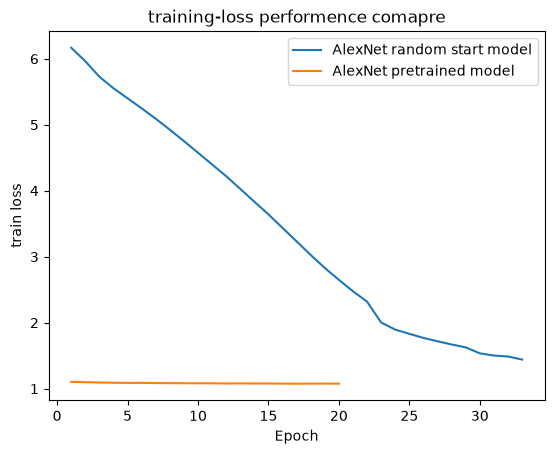

In [4]:
# train loss

for dt in range(len(json_data)):
    plt.plot(json_data[dt]["epoch"], json_data[dt]["train_loss"], label=model_name[json_file[dt].name], linestyle='-')

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("train loss")
plt.title("training-loss performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

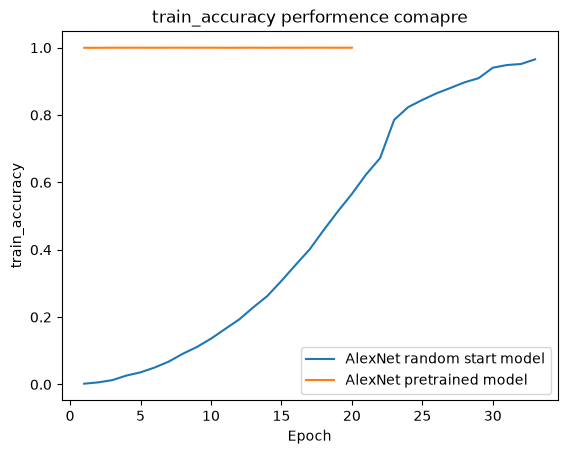

In [5]:
# train acc

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("train_accuracy")
plt.title("train_accuracy performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

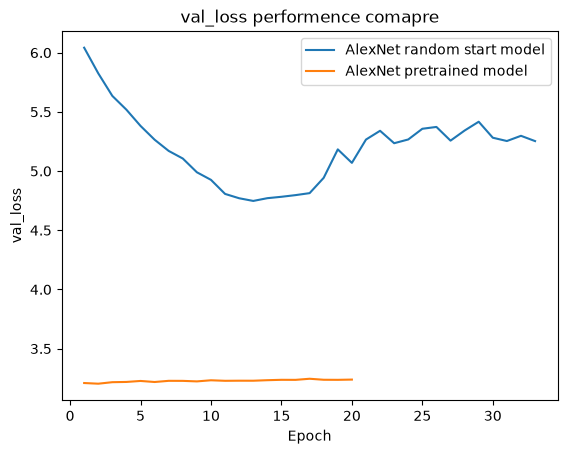

In [6]:
# val loss


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("val_loss")
plt.title("val_loss performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

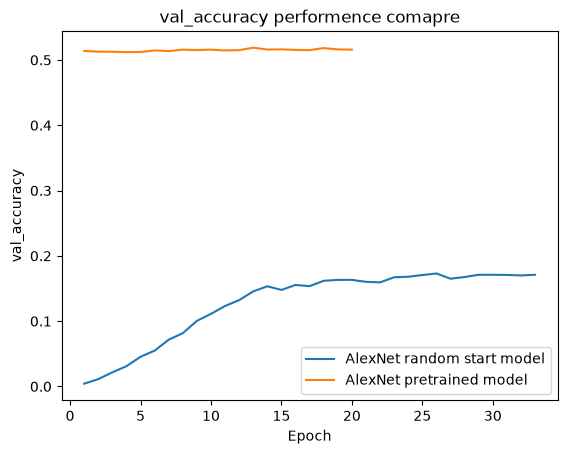

In [7]:
# train acc


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("val_accuracy")
plt.title("val_accuracy performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

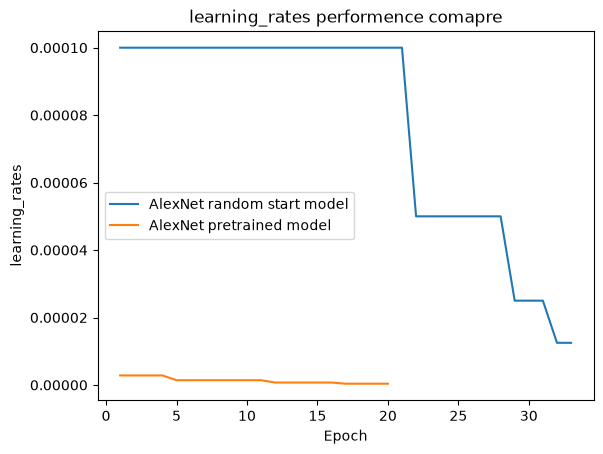

In [8]:
# learning rate

for dt in range(len(json_data)):
    if type(json_data[dt]['learning_rates'][0]) == list:
        row_averages = [sum(row) / len(row) for row in json_data[dt]['learning_rates']]
        plt.plot(json_data[dt]['epoch'], row_averages, label=model_name[json_file[dt].name], linestyle="-")

    else:
        plt.plot(json_data[dt]['epoch'], json_data[dt]['learning_rates'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("learning_rates")
plt.title("learning_rates performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib